# Tutorial: Understanding How Network Depth Affects Multilayer Perceptron Performance  
### A Practical Experiment Using the Wine Classification Dataset

📂 **GitHub Repository:** [Link to Repository](https://github.com/Hemantpawar1996/MLP-Network-Depth-Tutorial.git)

This notebook accompanies the tutorial for the Machine Learning assignment and demonstrates how **the number of hidden layers (network depth)** influences the performance of a **Multilayer Perceptron (MLP)**.  

The goal of this tutorial is to provide a clear, educational walkthrough that helps readers understand:

- What "depth" means in the context of neural networks  
- How increasing hidden layers changes model capacity and generalisation  
- Why deeper networks can sometimes perform worse than shallow ones  
- How to systematically compare neural network architectures  
- How to evaluate models using accuracy, confusion matrices and classification metrics  

### What this notebook includes:
- Loading and preprocessing the Wine dataset  
- Building several MLP architectures with different depths  
- Training models with consistent hyperparameters for fair comparison  
- Plotting train/test accuracy across architectures  
- Visualising mistakes using a confusion matrix  
- Interpreting results in the context of neural network theory  

This notebook is designed to be **fully reproducible**, **educational**, and easy to extend.  
All experiments in this notebook support the written tutorial submitted as a PDF.

---

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading a built-in dataset and essential ML tools
from sklearn.datasets import load_wine

# Utilities for splitting data into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler helps bring all features to the same scale
from sklearn.preprocessing import StandardScaler

# MLPClassifier is our neural network model for classification
from sklearn.neural_network import MLPClassifier

# Metrics to evaluate how well our model performs
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Load and Inspect the Dataset

Load the Wine dataset and inspect basic info

In [2]:
# Load the Wine dataset from scikit-learn
wine = load_wine()

# Separating the input features and the target labels
X = wine.data          # all feature values
y = wine.target        # class labels for each wine sample (3 classes)

# Storing feature and class names for easy reference
feature_names = wine.feature_names
target_names = wine.target_names

# Quick checks to understand what our dataset looks like
print("Feature names:", feature_names)
print("Target classes:", target_names)
print("Shape of X:", X.shape)   # number of samples and features
print("Shape of y:", y.shape)   # number of labels

# Creating a small DataFrame just to get a feel of the data
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y        # adding the label column to the table
df.head()               # show the first few rows

Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target classes: ['class_0' 'class_1' 'class_2']
Shape of X: (178, 13)
Shape of y: (178,)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# Train-test split

In [ ]:
# Splitting the dataset into training and testing sets
# We keep 20 percent data aside for testing to measure model performance later.
# 'stratify=y' ensures all 3 wine classes stay balanced in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# A quick look at the shapes to confirm everything split correctly
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (142, 13) Test shape: (36, 13)


# Standardise features

In [ ]:
# Standardizing the features so the neural network trains more smoothly
# We fit the scaler on the training data and apply the same transformation to the test data.
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Only transform the test data (never fit on test data)
X_test_scaled = scaler.transform(X_test)

# Define architectures with different depths

We define several MLP architectures with increasing depth:
- Shallow: 1 hidden layer
- Medium: 2 hidden layers
- Deep: 3 hidden layers

Very deep (for this small dataset): 5 hidden layers

In [ ]:
# Defining a few neural network architectures to experiment with.
# Each tuple represents the number of neurons in each hidden layer.
architectures = {
    "1-layer (32)": (32,),
    "2-layer (64, 32)": (64, 32),
    "3-layer (128, 64, 32)": (128, 64, 32),
    "5-layer (128, 64, 32, 16, 8)": (128, 64, 32, 16, 8)
}

# This list will hold accuracy and training time results for each architecture
results = []

# Storing trained models so we can inspect them later (e.g., confusion matrix)
trained_models = {}

# Train models and record performance

We train one MLP per architecture and record train/test accuracy.

In [ ]:
# Loop through each network architecture and train a separate MLP model
for name, hidden_sizes in architectures.items():
    print(f"\nTraining architecture: {name} with hidden layers {hidden_sizes}")

    # Creating the MLP model with the selected architecture
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_sizes,   # structure of the hidden layers
        activation='relu',                 # common activation for deep networks
        solver='adam',                     # optimizer for training
        max_iter=500,                      # max training iterations
        random_state=42,                   # keep results reproducible
        early_stopping=True,               # stop training when validation loss stops improving
        n_iter_no_change=20,               # patience for early stopping
        validation_fraction=0.1            # fraction of data used for validation
    )

    # Train the neural network on the scaled training data
    mlp.fit(X_train_scaled, y_train)

    # Predictions for both training and test sets
    y_train_pred = mlp.predict(X_train_scaled)
    y_test_pred = mlp.predict(X_test_scaled)

    # Calculating accuracy to see how well each architecture performs
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Displaying basic results for each model
    print(f"Train accuracy: {train_acc:.3f}")
    print(f"Test accuracy:  {test_acc:.3f}")
    print(f"Number of iterations until convergence: {mlp.n_iter_}")

    # Saving results for later comparison
    results.append({
        "architecture": name,
        "hidden_layers": hidden_sizes,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "n_iter": mlp.n_iter_
    })

    # Keeping the trained model in case we want confusion matrices, etc.
    trained_models[name] = mlp

# Convert the results into a DataFrame to view them neatly
results_df = pd.DataFrame(results)
results_df


Training architecture: 1-layer (32) with hidden layers (32,)
Train accuracy: 0.746
Test accuracy:  0.806
Number of iterations until convergence: 36

Training architecture: 2-layer (64, 32) with hidden layers (64, 32)
Train accuracy: 0.845
Test accuracy:  0.778
Number of iterations until convergence: 34

Training architecture: 3-layer (128, 64, 32) with hidden layers (128, 64, 32)
Train accuracy: 0.930
Test accuracy:  0.917
Number of iterations until convergence: 31

Training architecture: 5-layer (128, 64, 32, 16, 8) with hidden layers (128, 64, 32, 16, 8)
Train accuracy: 0.401
Test accuracy:  0.389
Number of iterations until convergence: 22


,architecture,hidden_layers,train_accuracy,test_accuracy,n_iter
0,1-layer (32),"(32,)",0.746479,0.805556,36
1,"2-layer (64, 32)","(64, 32)",0.845070,0.777778,34
2,"3-layer (128, 64, 32)","(128, 64, 32)",0.929577,0.916667,31
3,"5-layer (128, 64, 32, 16, 8)","(128, 64, 32, 16, 8)",0.401408,0.388889,22


# Plot train vs test accuracy for each architecture

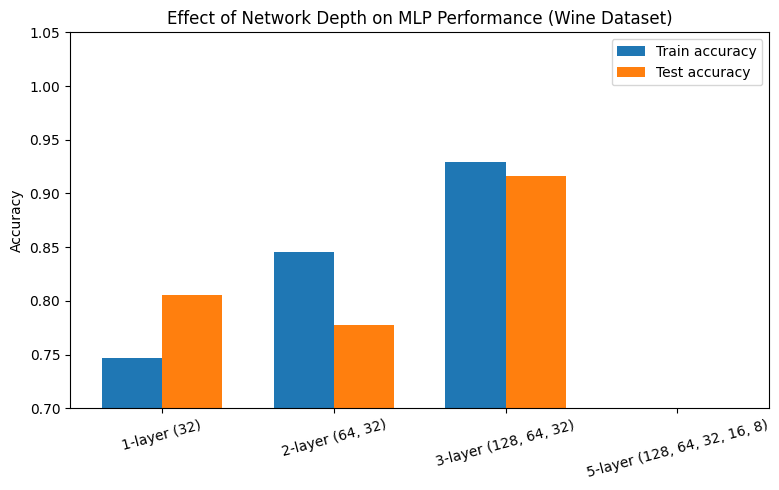

In [ ]:
# Plotting a side-by-side bar chart to compare train and test accuracy
plt.figure(figsize=(8, 5))

# Setting up bar positions on the x-axis
x = np.arange(len(results_df))
width = 0.35  # width of each bar

# Bars for training accuracy
plt.bar(x - width/2, results_df["train_accuracy"], width, label="Train accuracy")

# Bars for testing accuracy
plt.bar(x + width/2, results_df["test_accuracy"], width, label="Test accuracy")

# Labeling each bar group with the architecture name
plt.xticks(x, results_df["architecture"], rotation=15)

# Setting y-axis range to make differences easier to see
plt.ylim(0.7, 1.05)
plt.ylabel("Accuracy")

# Title for context
plt.title("Effect of Network Depth on MLP Performance (Wine Dataset)")

# Adding legend and tightening layout
plt.legend()
plt.tight_layout()

# Show the final plot
plt.show()

# Select the best model based on test accuracy

In [ ]:
# Find the architecture that achieved the highest test accuracy
best_row = results_df.iloc[results_df["test_accuracy"].idxmax()]
best_name = best_row["architecture"]

# Retrieve the trained model for that architecture
best_model = trained_models[best_name]

# Print a quick summary of the best-performing network
print("Best architecture:", best_name)
print("Hidden layers:", best_row["hidden_layers"])
print(f"Train accuracy: {best_row['train_accuracy']:.3f}")
print(f"Test accuracy:  {best_row['test_accuracy']:.3f}")

Best architecture: 3-layer (128, 64, 32)
Hidden layers: (128, 64, 32)
Train accuracy: 0.930
Test accuracy:  0.917


# Confusion matrix for best model

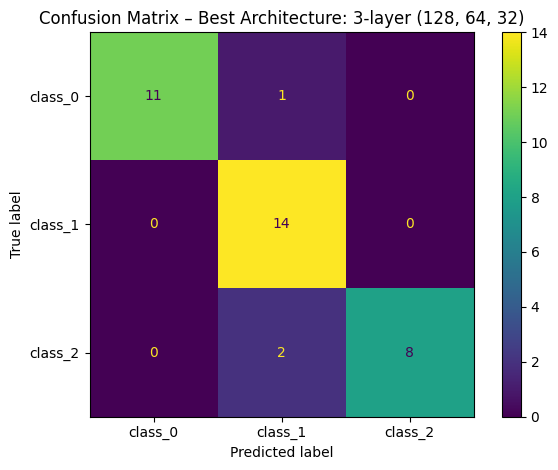

In [ ]:
# Using the best model to make predictions on the test set
y_test_pred_best = best_model.predict(X_test_scaled)

# Creating a confusion matrix to see how well the model classified each wine class
cm = confusion_matrix(y_test, y_test_pred_best)

# Visualizing the confusion matrix with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(values_format='d')

# Adding a clear title for context
plt.title(f"Confusion Matrix – Best Architecture: {best_name}")

# Clean layout + saving a high-resolution image of the plot
plt.tight_layout()
plt.savefig("mlp_best_confusion_matrix_wine.png", dpi=300)

# Displaying the plot
plt.show()

# Classification report for best model

In [ ]:
# Showing a detailed classification report for the best-performing model
# This includes precision, recall, F1-score, and support for each wine class.
print("Classification report for best model:")
print(classification_report(y_test, y_test_pred_best, target_names=target_names))

Classification report for best model:
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.82      1.00      0.90        14
     class_2       1.00      0.80      0.89        10

    accuracy                           0.92        36
   macro avg       0.94      0.91      0.92        36
weighted avg       0.93      0.92      0.92        36

